# Band Structures of Bulk Solids

This notebook connects three complementary descriptions of bulk electronic structure: a self-consistent ground state, the density of states (DOS), and the dispersion of individual bands through reciprocal space. Silver (Ag) provides a simple face-centered-cubic metal, while iron (Fe) introduces a magnetic body-centered-cubic example.

### Learning goals

- calculate and save a periodic GPAW ground state;
- construct a DOS with energies referenced to the Fermi level;
- identify a crystal's Bravais lattice and special $k$-points;
- evaluate bands along a chosen high-symmetry path using a fixed density; and
- recognize when orbital, spin, convergence, and lattice-path information are needed for a defensible interpretation.

Energies are reported in electronvolts (eV), DOS values in states per eV for the computational cell, and reciprocal-space coordinates in the basis of the reciprocal lattice vectors. Unless stated otherwise, $E-E_{\mathrm{F}}=0$ marks the Fermi level. The numerical settings below are suitable for learning the workflow, but they should be converged before quantitative use.

## Imports

Matplotlib provides the plots, GPAW performs the plane-wave DFT calculations, and ASE supplies the bulk structures, reciprocal-space paths, and DOS interface.

In [1]:
import matplotlib.pyplot as plt
from gpaw import GPAW, PW

from ase.build import bulk
from ase.dft.dos import DOS

## Build the Ag primitive cell

`bulk('Ag')` constructs ASE's default bulk Ag structure: a one-atom primitive cell of the face-centered-cubic (FCC) crystal. The cell geometry determines both the real-space periodicity and the reciprocal lattice used later for the band path.

In [2]:
atoms = bulk('Ag')

## Bulk Ag ground-state calculation

The calculator uses a plane-wave basis with a kinetic-energy cutoff of 350 eV and an $8 \times 8 \times 8$ Monkhorst-Pack $k$-point mesh. The `Ag: 11` setup requests an Ag PAW dataset with 11 valence electrons. GPAW's text output is written separately so that convergence and calculator details remain auditable.

The cutoff, $k$-point mesh, electronic occupations, and lattice constant all affect the final energies and bands. Here they define one internally consistent learning calculation; they are not yet a convergence study.

In [3]:
calc = GPAW(
    mode=PW(350), kpts=[8, 8, 8], txt='../files/advanced/tutorial_06/gpaw.bulk_Ag.txt', setups={'Ag': '11'}
)

### Attach the calculator and trigger self-consistency

ASE calculations are lazy: assigning `atoms.calc` only connects the objects, while requesting the potential energy starts the self-consistent-field calculation. The printed value is the total potential energy of this one-atom periodic cell. It is not a cohesive energy, and absolute totals from different elements should not be compared directly.

In [4]:
atoms.calc = calc
print(
    'Bulk {0} potential energy = {1:.3f}eV'.format(
        atoms.get_chemical_formula(), atoms.get_potential_energy()
    )
)

Bulk Ag potential energy = -3.667eV


### Save the converged state

The `.gpw` restart file stores the converged calculator state needed by the later DOS and fixed-density calculations. Reusing it avoids repeating the ground-state self-consistency cycle and ensures that the analyses share the same electronic density.

In [5]:
ground_state_file = '../files/advanced/tutorial_06/bulk_Ag_groundstate.gpw'
calc.write(ground_state_file)

## Density of states

The DOS counts how many one-electron states occur in each energy interval:

$$
g(E)=\sum_{n,\mathbf{k}} w_{\mathbf{k}}\,\delta(E-\varepsilon_{n\mathbf{k}}).
$$

ASE shifts the eigenvalues by the Fermi energy, so $E-E_{\mathrm{F}}=0$ separates occupied and unoccupied states at zero temperature. With `width=0`, ASE uses linear tetrahedron interpolation on the regular $k$-point grid instead of adding Gaussian broadening. The 800 points control how finely the resulting curve is sampled; they do not replace convergence with respect to the underlying $k$-point mesh.

In [6]:
calc = GPAW(ground_state_file)
dos = DOS(calc, npts=800, width=0)
energies = dos.get_energies()
weights = dos.get_dos()

### Plot the Ag DOS

The vertical dashed line marks $E-E_{\mathrm{F}}=0$. States to its left are occupied in the ground-state picture; states to its right are unoccupied Kohn-Sham states.

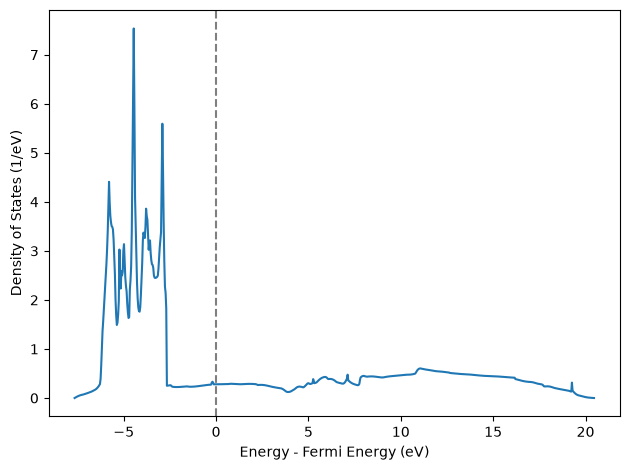

In [7]:
fig, ax = plt.subplots()
ax.axvline(0.0, linestyle='--', color='black', alpha=0.5)
ax.plot(energies, weights)
ax.set_xlabel('Energy - Fermi Energy (eV)')
ax.set_ylabel('Density of States (1/eV)')
fig.tight_layout()

### Interpreting the Ag DOS

A useful first question is which parts of the spectrum are mainly $s$-like and which are mainly $d$-like. Localized atomic $d$ orbitals generally overlap less strongly between neighboring atoms than the more delocalized $s$ orbitals. In a solid, weaker overlap produces a comparatively narrow $d$ band, while stronger overlap produces a broader $sp$-derived band. The fivefold orbital degeneracy of the $d$ manifold also helps make its DOS large.

For this Ag result, the prominent occupied feature from approximately -6.2 to -2.6 eV is expected to be predominantly $4d$-derived. The lower-amplitude states spread across a wider energy range, including the states crossing $E_{\mathrm{F}}$, are expected to contain more $5s$ and $5p$ character. This is a chemically motivated assignment, not a direct measurement: a projected DOS is required to separate the $s$, $p$, and $d$ contributions explicitly.

Ag is a noble metal, and its $d$ manifold lies below the Fermi level while a more dispersive band crosses $E_{\mathrm{F}}$. By contrast, many other transition metals have a partially occupied $d$ manifold and therefore substantial $d$ character at the Fermi level.

> **Caution about unoccupied states:** the states above $E_{\mathrm{F}}$ are Kohn-Sham eigenvalues evaluated for a ground-state density. Their number and high-energy accuracy depend on the requested bands and basis settings, and ordinary ground-state DFT eigenvalues are not quasiparticle excitation energies. Near-Fermi trends can still be informative, but high unoccupied states should not be interpreted quantitatively without additional convergence checks and, where needed, a more appropriate excited-state method.

## Reciprocal space and band structure

The DOS integrates information across the Brillouin zone, whereas a band structure retains the wave-vector dependence $\varepsilon_n(\mathbf{k})$. It therefore reveals which bands are flat or dispersive, where bands cross the Fermi level, and how crystal symmetry organizes the electronic states.

The next cell reconstructs the Ag cell and asks ASE to identify its Bravais lattice, special reciprocal-space points, and a conventional default path.

In [8]:
atoms = bulk('Ag')

lat = atoms.cell.get_bravais_lattice()
print(lat.description())

FCC(a=4.09)
  Variant name: FCC
  Special point names: GKLUWX
  Default path: GXWKGLUWLK,UX

  Special point coordinates:
    G   0.0000  0.0000  0.0000
    K   0.3750  0.3750  0.7500
    L   0.5000  0.5000  0.5000
    U   0.6250  0.2500  0.6250
    W   0.5000  0.2500  0.7500
    X   0.5000  0.0000  0.5000



### Inspect the first Brillouin zone

The Brillouin-zone drawing places the named special points on the FCC reciprocal-space polyhedron. These labels are lattice-specific: the same letter sequence must not be transferred to a structure with a different Bravais lattice.

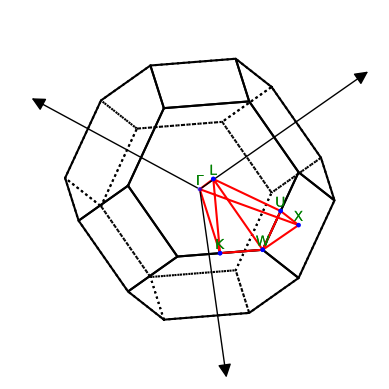

In [9]:
lat.plot_bz(show=True)
plt.show()

### Define a high-symmetry path

The path `WLGXWK` means $W \rightarrow L \rightarrow \Gamma \rightarrow X \rightarrow W \rightarrow K$ for the FCC cell. `density=10` controls the sampling density along this plotting path; it is separate from the uniform $8 \times 8 \times 8$ mesh used to converge the ground-state density. The path is saved as JSON so that its geometry can be inspected or reused.

In [10]:
path = atoms.cell.bandpath('WLGXWK', density=10)
path.write('../files/advanced/tutorial_06/path.json')
print(path)

BandPath(path='WLGXWK', cell=[3x3], special_points={GKLUWX}, kpts=[53x3])


### Visualize the selected route

Plotting the path before the electronic calculation is a useful geometry check: the connected segments should pass through the intended FCC special points in the intended order.

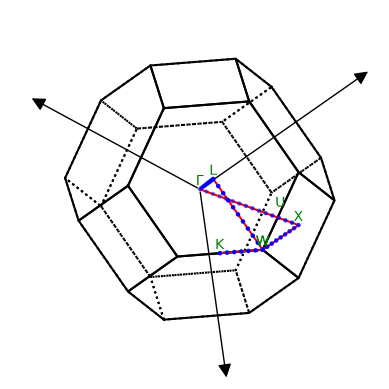

In [11]:
path.plot()
plt.show()

### Evaluate bands at fixed density

The converged Ag ground state is reloaded and diagonalized non-self-consistently at the $k$-points along the path. The electron density remains fixed, which is efficient because the path is intended for interpolation and visualization rather than for Brillouin-zone integration. Turning symmetry off preserves the explicitly requested sequence of path points.

This separation is important: a dense uniform mesh determines the ground-state density, while a connected high-symmetry path displays the resulting eigenvalue dispersion.

In [12]:
ground_state_file = '../files/advanced/tutorial_06/bulk_Ag_groundstate.gpw'
calc = GPAW(ground_state_file)
calc = calc.fixed_density(kpts=path, symmetry='off')


Diagonalizing LCAO Hamiltonian


Converting LCAO to pw mode


convergence criteria:
- Maximum integral of absolute [eigenst]ate change: 4e-08 eV^2 / valence electron
maximum number of iterations: 333



SCF iterations
|iter     |     time |      energy | eigst |  dens |
|---------|----------|-------------|-------|-------|
|iter:   1| 13:42:42 |             | -0.78 |       |


|iter:   2| 13:42:43 |             | -2.73 |       |


...

|iter:   4| 13:42:43 |             | -5.05 |       |


|iter:   5| 13:42:43 |             | -5.85 |       |


|iter:   6| 13:42:44 |             | -7.14 |       |


|iter:   7| 13:42:44 |             | -7.72c|       |


SCF steps: 7
  __  _  _
 | _ |_)|_||  |
 |__||  | ||/\| - 26.7.0

User:   liangze@Angzes-MacBook-Pro.local
Date:   Sun Aug  9 13:42:44 2026
Arch:   arm64
Pid:    43974
CWD:    /Users/liangze/Desktop/Experiences/ase_learning/official_tutorials_advanced
units:  Angstrom and eV
cores:  1
OpenMP: False

Versions:
  Python: 3.14.6
  ASE:    3.29.0
  Numpy:  2.5.1
  Scipy:  1.18.0
  Libxc:  2.x.y

Paths:
  gpaw:  /Users/liangze/Desktop/Experiences/ase_learning/.venv/lib/python3.14/site-packages/gpaw
  _gpaw: /Users/liangze/Desktop/Experiences/ase_learning/.venv/lib/python3.14/site-packages/
        _gpaw.cpython-314-darwin.so
  ase:   /Users/liangze/Desktop/Experiences/ase_learning/.venv/lib/python3.14/site-packages/ase
  numpy: /Users/liangze/Desktop/Experiences/ase_learning/.venv/lib/python3.14/site-packages/numpy
  scipy: /Users/liangze/Desktop/Experiences/ase_learning/.venv/lib/python3.14/site-packages/scipy

Git-hashes:

OMP_NUM_THREADS: 


Environment variables:
  GPAW_CPUPY:          

### Collect and save the Ag bands

`band_structure()` packages the path, eigenvalues, and reference energy into an ASE `BandStructure` object. Saving it to JSON decouples plotting from the GPAW calculation and makes the numerical band data easy to revisit.

In [13]:
bs = calc.band_structure()
bs.write('../files/advanced/tutorial_06/bs.json')
print(bs)

BandStructure(path=BandPath(path='WLGXWK', cell=[3x3], special_points={GKLUWX}, kpts=[53x3]), energies=[1x53x9 values], reference=7.039838319848633)


### Plot and inspect the Ag dispersion

The inline plot shows how the eigenvalues change along the FCC path. A band crossing the Fermi reference is the reciprocal-space signature of metallic behavior. Relatively flat groups of bands contribute many states within a narrow energy interval and therefore tend to coincide with large DOS features; strongly dispersive bands spread their states over a wider energy range.

The saved file can also be plotted from a terminal. From the notebook directory, use:

```bash
ase band-structure ../files/advanced/tutorial_06/bs.json
```

The shorter command `ase band-structure bs.json` works only when the current directory already contains `bs.json`. For a direct comparison with the DOS, label or transform the band-energy axis consistently so that the Fermi reference corresponds to $E-E_{\mathrm{F}}=0$.

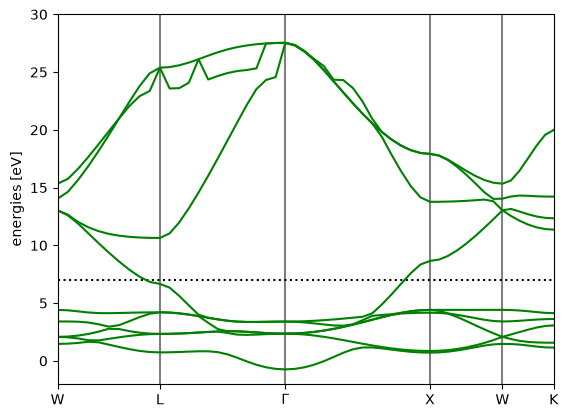

In [14]:
ax = bs.plot()
ax.set_ylim(-2.0, 30.0)
plt.show()

## BCC Fe: a lattice-specific reciprocal-space path

A band structure samples eigenvalues along a path through reciprocal space, and the conventional high-symmetry points depend on the real-space Bravais lattice. Ag is FCC, whereas `bulk('Fe')` constructs BCC Fe. The FCC Ag path therefore cannot serve as the standard path for Fe.

GPAW can mathematically evaluate Fe eigenvalues at coordinates copied from the Ag calculation, so the calculation may still finish. The problem is crystallographic: FCC labels such as $W$, $L$, and $X$ do not describe the standard BCC symmetry directions, making the plotted x-axis physically misleading.

The cells below ask ASE to identify the Fe lattice and generate its standard path directly from the Fe cell. For BCC, ASE uses the special points $\Gamma$, $H$, $P$, and $N$. The same `path_fe` object is then passed to the fixed-density band calculation, removing any dependency on the earlier Ag path.

BCC(a=2.87)
  Variant name: BCC
  Special point names: GHPN
  Default path: GHNGPH,PN

  Special point coordinates:
    G   0.0000  0.0000  0.0000
    H   0.5000 -0.5000  0.5000
    P   0.2500  0.2500  0.2500
    N   0.0000  0.0000  0.5000

Fe high-symmetry path: GHNGPH,PN
BandPath(path='GHNGPH,PN', cell=[3x3], special_points={GHNP}, kpts=[100x3])

timing:  # [seconds]
  Total: 0.054  # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Max RSS: 208.391  # MiB


Bulk Fe potential energy = -9.833eV



Diagonalizing LCAO Hamiltonian


Converting LCAO to pw mode


convergence criteria:
- Maximum integral of absolute [eigenst]ate change: 4e-08 eV^2 / valence electron
maximum number of iterations: 333



...

|iter:  15| 13:42:57 |             | -7.01 |       |  +2.1599|


|iter:  16| 13:42:57 |             | -7.18 |       |  +2.1599|


|iter:  17| 13:42:57 |             | -7.33 |       |  +2.1599|


|iter:  18| 13:42:58 |             | -7.49c|       |  +2.1599|


SCF steps: 18
  __  _  _
 | _ |_)|_||  |
 |__||  | ||/\| - 26.7.0

User:   liangze@Angzes-MacBook-Pro.local
Date:   Sun Aug  9 13:42:58 2026
Arch:   arm64
Pid:    43974
CWD:    /Users/liangze/Desktop/Experiences/ase_learning/official_tutorials_advanced
units:  Angstrom and eV
cores:  1
OpenMP: False

Versions:
  Python: 3.14.6
  ASE:    3.29.0
  Numpy:  2.5.1
  Scipy:  1.18.0
  Libxc:  2.x.y

Paths:
  gpaw:  /Users/liangze/Desktop/Experiences/ase_learning/.venv/lib/python3.14/site-packages/gpaw
  _gpaw: /Users/liangze/Desktop/Experiences/ase_learning/.venv/lib/python3.14/site-packages/
        _gpaw.cpython-314-darwin.so
  ase:   /Users/liangze/Desktop/Experiences/ase_learning/.venv/lib/python3.14/site-packages/ase
  numpy: /Users/liangze/Desktop/Experiences/ase_learning/.venv/lib/python3.14/site-packages/numpy
  scipy: /Users/liangze/Desktop/Experiences/ase_learning/.venv/lib/python3.14/site-packages/scipy

Git-hashes:

OMP_NUM_THREADS: 


Environment variables:
  GPAW_CPUPY:         

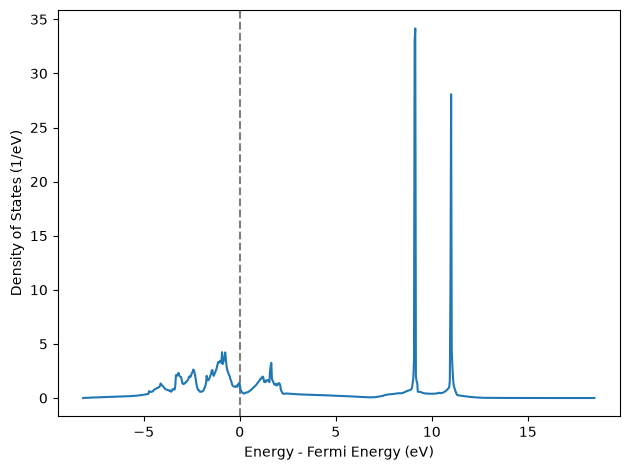

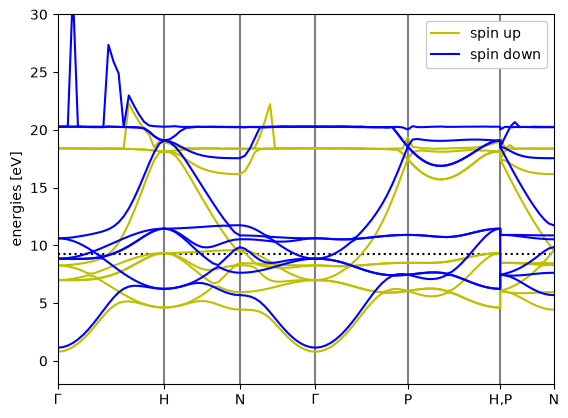

In [15]:
atoms = bulk('Fe')

lattice_fe = atoms.cell.get_bravais_lattice()
print(lattice_fe.description())

path_fe = atoms.cell.bandpath(npoints=100)
path_fe.write('../files/advanced/tutorial_06/path_Fe.json')
print(f'Fe high-symmetry path: {path_fe.path}')
print(path_fe)

calc = GPAW(
    mode=PW(350), kpts=[8, 8, 8], txt='../files/advanced/tutorial_06/gpaw.bulk_Fe.txt', setups={'Ag': '11'}
)

atoms.calc = calc
print(
    'Bulk {0} potential energy = {1:.3f}eV'.format(
        atoms.get_chemical_formula(), atoms.get_potential_energy()
    )
)

ground_state_file = '../files/advanced/tutorial_06/bulk_Fe_groundstate.gpw'
calc.write(ground_state_file)

calc = GPAW(ground_state_file)
dos = DOS(calc, npts=800, width=0)
energies = dos.get_energies()
weights = dos.get_dos()

fig, ax = plt.subplots()
ax.axvline(0.0, linestyle='--', color='black', alpha=0.5)
ax.plot(energies, weights)
ax.set_xlabel('Energy - Fermi Energy (eV)')
ax.set_ylabel('Density of States (1/eV)')
fig.tight_layout()

calc = GPAW(ground_state_file)
calc = calc.fixed_density(kpts=path_fe, symmetry='off')

bs = calc.band_structure()
bs.write('../files/advanced/tutorial_06/bs_Fe.json')
print(bs)

ax = bs.plot()
ax.set_ylim(-2.0, 30.0)
plt.show()

### Reading the Fe output

ASE identifies the Fe primitive cell as BCC and generates its band path from that cell. The band plot therefore carries BCC rather than FCC special-point labels. The existing total DOS still adds the two spin channels, so the exchange splitting is not yet visible there. The Ag and Fe total energies also belong to different chemical systems and cannot be ranked directly.

## Takeaways

- A ground-state calculation on a uniform $k$-point mesh supplies the density used by both DOS and band analyses.
- The DOS shows how states are distributed in energy; the band structure shows where those states occur in reciprocal space.
- Ag's narrow occupied feature is consistent with a filled $d$ manifold, but orbital projections are needed to verify that assignment.
- A high-symmetry path belongs to a particular reciprocal lattice. Reusing an FCC path for BCC Fe invalidates the symmetry interpretation.
- Magnetic Fe requires spin-resolved analysis, while quantitative conclusions require converged numerical settings.

## Recommended additions

The most valuable next addition is a corrected, Fermi-referenced Ag/Fe comparison that places the DOS and band structure side by side. Before expanding the physics, fix the Fe setup and rebuild its path from the BCC cell. Then add the following, in order of value:

1. **Make the Fe magnetism explicit.** Remove the Ag-specific setup mapping, initialise a nonzero Fe moment, request spin polarization, and report the converged magnetic moment and Fermi level.
2. **Use a common Fermi-zero energy axis.** Plot `bs.subtract_reference()` and label the axis $E-E_{\mathrm{F}}$ (eV). Include a focused window such as -8 to 8 eV; the present -2 to 30 eV view omits most of Ag's occupied $d$ band and emphasizes poorly converged high unoccupied states.
3. **Add orbital- and spin-resolved DOS.** Project Ag onto $s$, $p$, and $d$ channels to test the orbital assignment. For Fe, plot majority and minority DOS separately and relate their exchange splitting to the magnetic moment and spin-resolved bands.
4. **Document convergence.** Repeat representative quantities while increasing the plane-wave cutoff and $k$-point density, and test the DOS integration or broadening choice, lattice constant, number of bands, and occupation smearing. A compact convergence table would make the selected settings defensible.
5. **Include relativistic effects.** Compare Ag bands with and without spin-orbit coupling, especially near degeneracies. This becomes even more important if Au is added.
6. **Make the comparison quantitative.** Report the $d$-band center or integrated projected occupations, record the GPAW/ASE versions and PAW setups, and compare selected bands or DOS features with an experimental or higher-level reference.

Together, these additions would turn the notebook from a plotting demonstration into a reproducible electronic-structure comparison with clear numerical and physical checks.